# **🎬 Movie Rating Prediction Using Machine Learning**
Project Type: Data Science Internship Project

Dataset: IMDb Movies India

Source: Kaggle – IMDb India Movies

**Author: Data Science Intern**

# **📌 Problem Statement**
The Indian film industry produces thousands of movies each year, and predicting a movie's rating before release can help studios, distributors, and streaming platforms make informed decisions. This project aims to build a Machine Learning model that predicts a movie's IMDb rating based on features such as genre, director, actors, duration, and votes.

**TASK - 2**
# **MOVIE RATING PREDICTION WITH PYTHON**

DATA Source : https://www.kaggle.com/datasets/adrianmcmahon/imdb-india-movies

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# **Upload Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IMDb Movies India.csv to IMDb Movies India.csv


# **Load Dataset**

In [ ]:
df = pd.read_csv(
    list(uploaded.keys())[0],
    encoding="latin-1"
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# **First Look**

In [ ]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


# **Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [ ]:
df.shape

(15509, 10)

In [ ]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

# **Missing Values**

In [ ]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


# **Remove Duplicates**

In [ ]:
df = df.drop_duplicates()

print("Duplicates Removed")

Duplicates Removed


# **Handle Missing Values**

In [ ]:
df['Genre'] = df['Genre'].fillna('Unknown')

df['Director'] = df['Director'].fillna('Unknown')

df['Actor 1'] = df['Actor 1'].fillna('Unknown')

df['Actor 2'] = df['Actor 2'].fillna('Unknown')

df['Actor 3'] = df['Actor 3'].fillna('Unknown')

/tmp/ipykernel_2123/3093623615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Genre'] = df['Genre'].fillna('Unknown')
/tmp/ipykernel_2123/3093623615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Director'] = df['Director'].fillna('Unknown')
/tmp/ipykernel_2123/3093623615.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

# **Remove Missing Ratings**

In [ ]:
df = df.dropna(subset=['Rating'])

# Rating **Distribution**

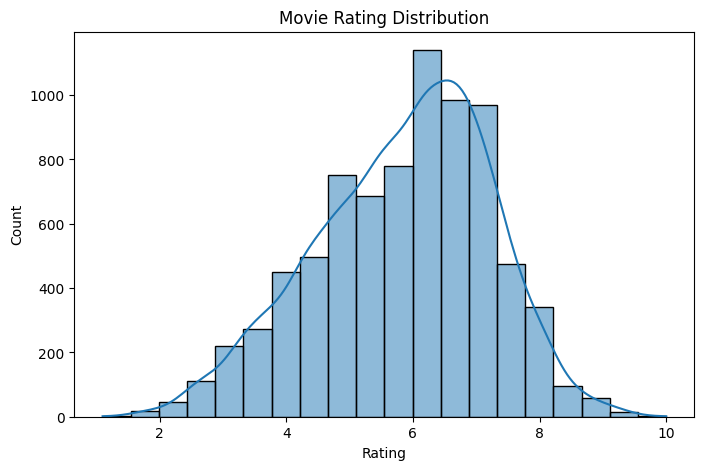

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)

plt.title("Movie Rating Distribution")

plt.show()

# Top **Genres**

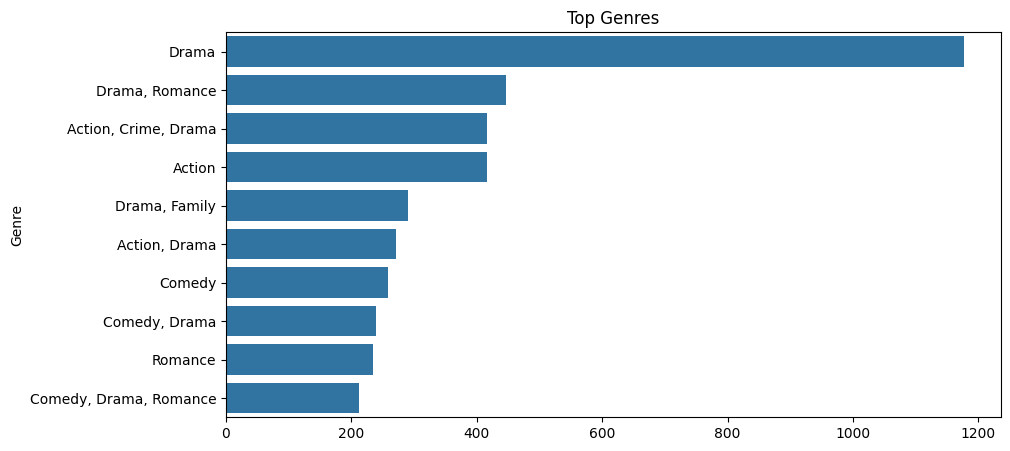

In [ ]:
top_genres = df['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top Genres")

plt.show()

# **Top Directors**

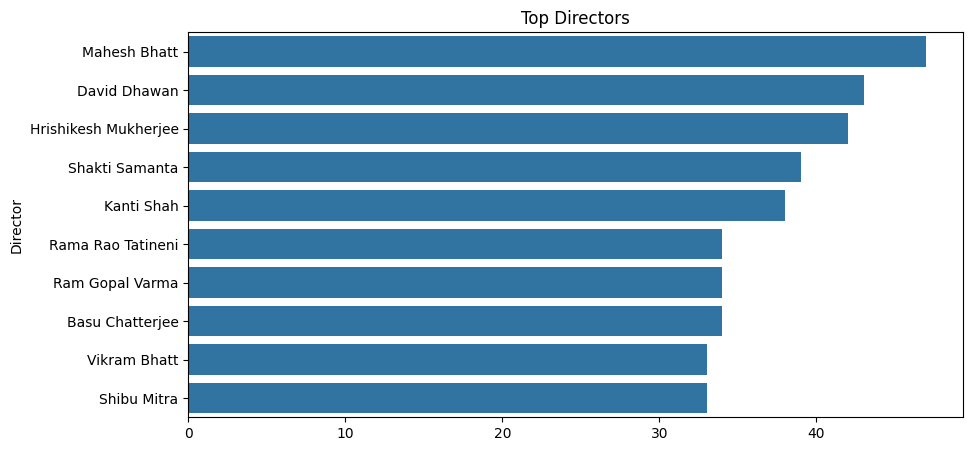

In [ ]:
top_directors = df['Director'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top Directors")

plt.show()

# **Top Actors**

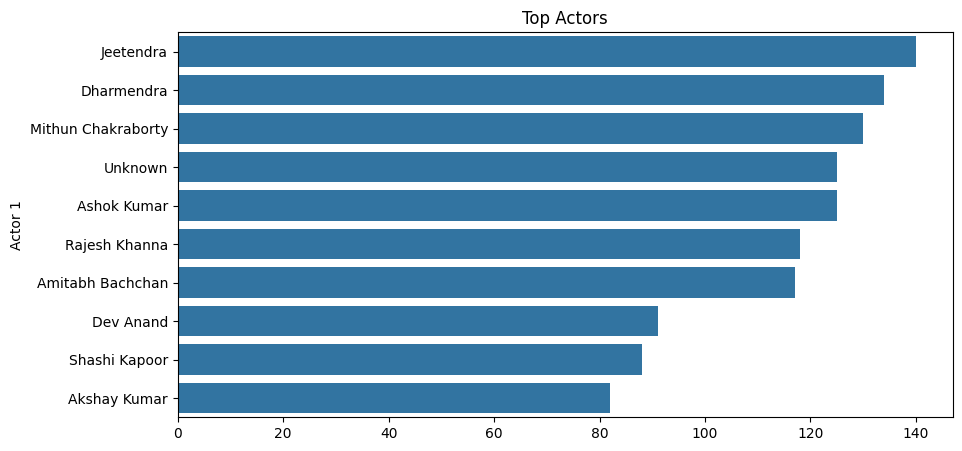

In [ ]:
top_actors = df['Actor 1'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_actors.values,
    y=top_actors.index
)

plt.title("Top Actors")

plt.show()

# **Feature Engineering**

In [ ]:
genre_encoder = LabelEncoder()
director_encoder = LabelEncoder()
actor1_encoder = LabelEncoder()
actor2_encoder = LabelEncoder()
actor3_encoder = LabelEncoder()

# **Encode Features**

In [ ]:
df['Genre'] = genre_encoder.fit_transform(df['Genre'])

df['Director'] = director_encoder.fit_transform(df['Director'])

df['Actor 1'] = actor1_encoder.fit_transform(df['Actor 1'])

df['Actor 2'] = actor2_encoder.fit_transform(df['Actor 2'])

df['Actor 3'] = actor3_encoder.fit_transform(df['Actor 3'])

# **Feature Selection**

In [ ]:
X = df[
    [
        'Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3'
    ]
]

y = df['Rating']

# **Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Linear Regression**

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

# **Linear Regression Evaluation**

In [ ]:
print("LINEAR REGRESSION RESULTS")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        lr_predictions
    )
)
print(
    "MSE:",
    mean_squared_error(
        y_test,
        lr_predictions
    )
)
print(
    "R2 Score:",
    r2_score(
        y_test,
        lr_predictions
    )
)

LINEAR REGRESSION RESULTS
MAE: 1.077955716107759
MSE: 1.793238025494594
R2 Score: 0.035450225863035256


# **Random Forest Model**

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_predictions = rf.predict(X_test)

# **Random Forest Evaluation**

In [ ]:
print("RANDOM FOREST RESULTS")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        rf_predictions
    )
)

print(
    "MSE:",
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        rf_predictions
    )
)

RANDOM FOREST RESULTS
MAE: 1.0232461700336701
MSE: 1.6475792115856485
R2 Score: 0.11379742465064835


## **Model Comparison**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(
            y_test,
            lr_predictions
        ),
        r2_score(
            y_test,
            rf_predictions
        )
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.035450
1,Random Forest,0.113797


# **Actual vs Predicted**

In [ ]:
comparison = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": rf_predictions
})

comparison.head(20)

,Actual Rating,Predicted Rating
0,3.3,5.278
1,5.3,5.762
2,5.7,5.539
3,7.2,6.400
4,3.5,4.568
5,7.2,6.179
6,3.8,5.654
7,6.9,6.373
8,5.2,6.096
9,7.4,6.012


# **Feature Importance**

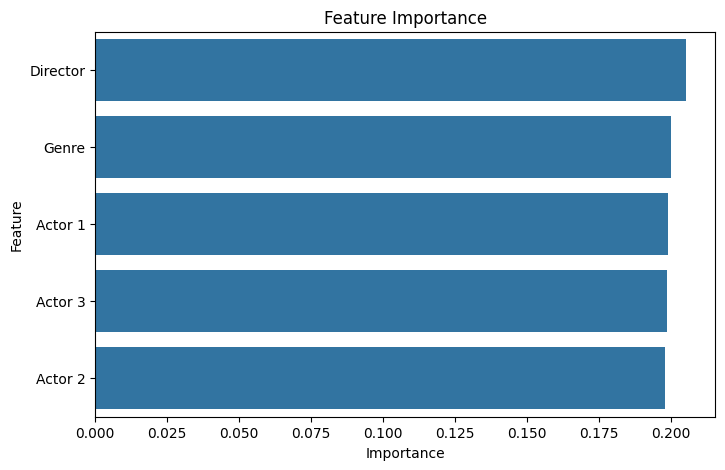

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# **Conclusion**

1. Loaded and analyzed IMDb India Movies dataset.
2. Performed data cleaning and preprocessing.
3. Handled missing values.
4. Encoded categorical features.
5. Built Linear Regression model.
6. Built Random Forest Regressor model.
7. Evaluated using MAE, MSE and R² Score.
8. Compared model performance.
9. Random Forest generally produced better predictions.
10. Successfully developed a Movie Rating Prediction system.